# 1 Creating and Manipulating Arrays

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan

In [2]:
# 1D arrays
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

xx, yy = np.meshgrid(x, y)

xx.shape, yy.shape

((100, 100), (100, 100))

## 1.2. Visualize each 2D array using pcolormesh

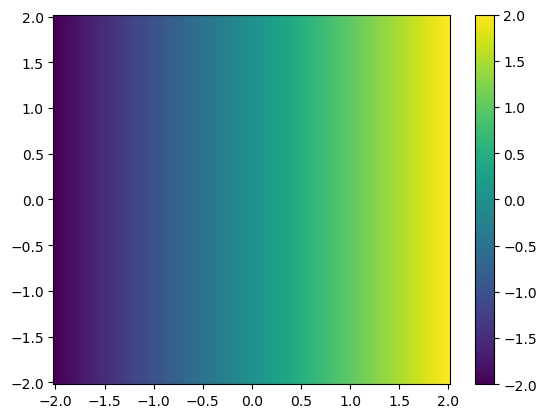

In [58]:
plt.pcolormesh(xx, yy, xx)
plt.colorbar()
plt.show()

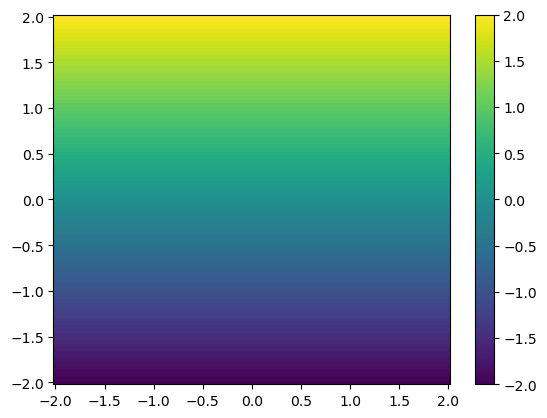

In [59]:
plt.pcolormesh(xx, yy, yy)
plt.colorbar()
plt.show()

## 1.3 Convert to polar coordinates

In [5]:
r = np.sqrt(xx**2 + yy**2)
phi = np.arctan2(yy, xx)

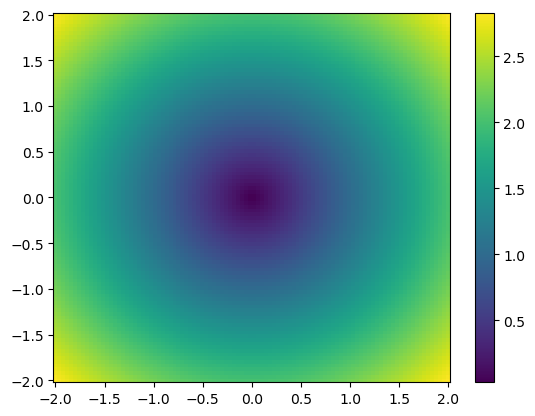

In [60]:
plt.pcolormesh(xx, yy, r)
plt.colorbar()
plt.show()

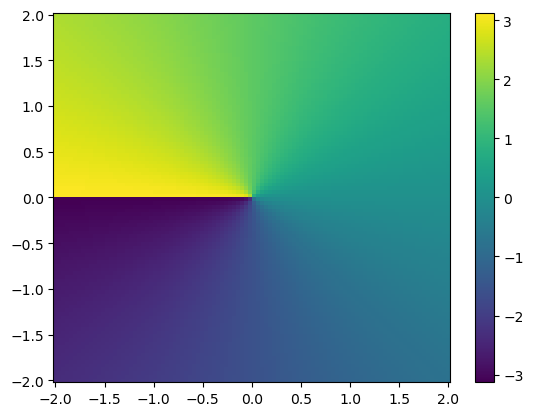

In [61]:
plt.pcolormesh(xx, yy, phi)
plt.colorbar()
plt.show()

## 1.4 

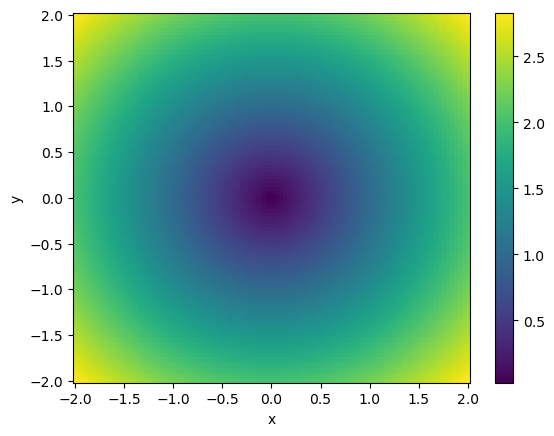

In [8]:
plt.pcolormesh(x, y, r)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

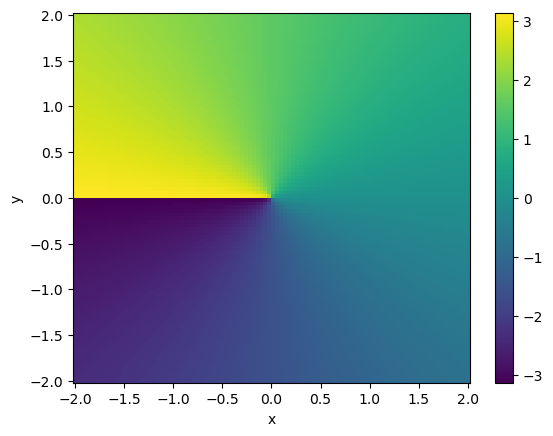

In [9]:
plt.pcolormesh(x, y, phi)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 1.5 Caclulate the quanity 

In [12]:
f = np.cos(4*r)**2 + np.sin(4*phi)**2
f

array([[0.09784068, 0.04288054, 0.0152121 , ..., 0.0152121 , 0.04288054,
        0.09784068],
       [0.04288054, 0.00800214, 0.00231617, ..., 0.00231617, 0.00800214,
        0.04288054],
       [0.0152121 , 0.00231617, 0.01919286, ..., 0.01919286, 0.00231617,
        0.0152121 ],
       ...,
       [0.0152121 , 0.00231617, 0.01919286, ..., 0.01919286, 0.00231617,
        0.0152121 ],
       [0.04288054, 0.00800214, 0.00231617, ..., 0.00231617, 0.00800214,
        0.04288054],
       [0.09784068, 0.04288054, 0.0152121 , ..., 0.0152121 , 0.04288054,
        0.09784068]])

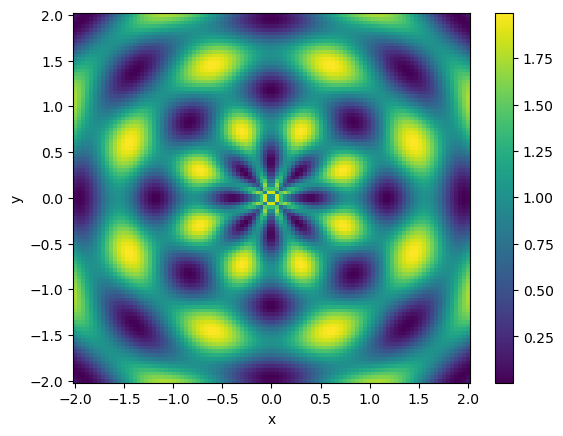

In [13]:
plt.pcolormesh(x, y, f)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Part 2: Analyze ARGO Data

In [14]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

Unzipping contents of '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

In [32]:
files

['/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/wt2394/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

## 2.1 Load each data file as a numpy array

In [33]:
T = np.load([f for f in files if f.endswith("T.npy")][0])
S = np.load([f for f in files if f.endswith("S.npy")][0])
P = np.load([f for f in files if f.endswith("P.npy")][0])

date = np.load([f for f in files if f.endswith("date.npy")][0])
lat = np.load([f for f in files if f.endswith("lat.npy")][0])
lon = np.load([f for f in files if f.endswith("lon.npy")][0])

level = np.load([f for f in files if f.endswith("levels.npy")][0])

In [34]:
T.shape

(78, 75)

In [35]:
S.shape

(78, 75)

In [36]:
P.shape

(78, 75)

In [37]:
lat.shape

(75,)

In [38]:
lon.shape

(75,)

In [39]:
level.shape

(78,)

### 2.2 Relationship between shapes

T, S and P have shape (78, 75).

lat, lon and date have shape (75,).

level has shape (78,).

This suggests that:

- 75 corresponds to the number of profiles.
- 78 corresponds to the number of depth levels.

Therefore:

- The second dimension of T, S and P (size 75) is shared with lat, lon and date.
- The first dimension of T, S and P (size 78) is shared with level.

So the data structure appears to be:

(depth, profile)

## 2.3 Make a plot for each column of data in T, S and P (three plots)

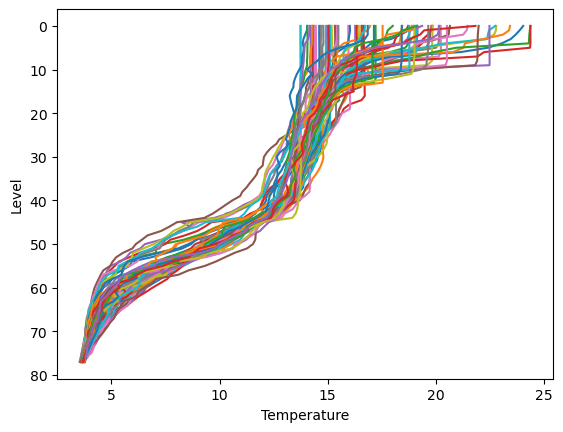

In [40]:
plt.figure()
plt.plot(T, level)
plt.xlabel("Temperature")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

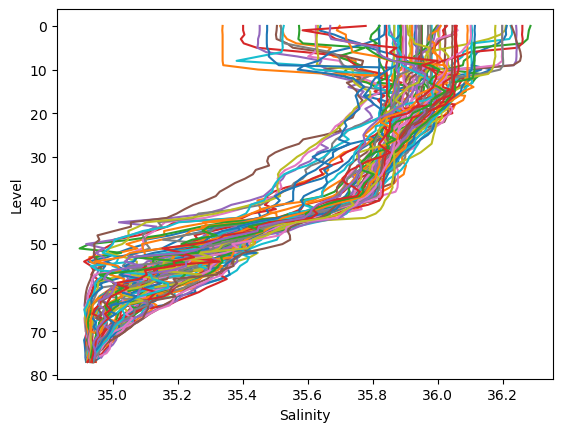

In [41]:
plt.figure()
plt.plot(S, level)
plt.xlabel("Salinity")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

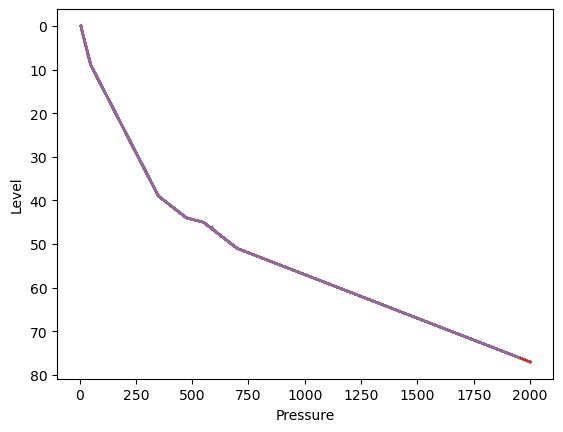

In [42]:
plt.figure()
plt.plot(P, level)
plt.xlabel("Pressure")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

## 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [44]:
T_mean = np.mean(T, axis=1)
T_std  = np.std(T, axis=1)

S_mean = np.mean(S, axis=1)
S_std  = np.std(S, axis=1)

P_mean = np.mean(P, axis=1)
P_std  = np.std(P, axis=1)

In [45]:
T_mean.shape
S_mean.shape
P_mean.shape

(78,)

## 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

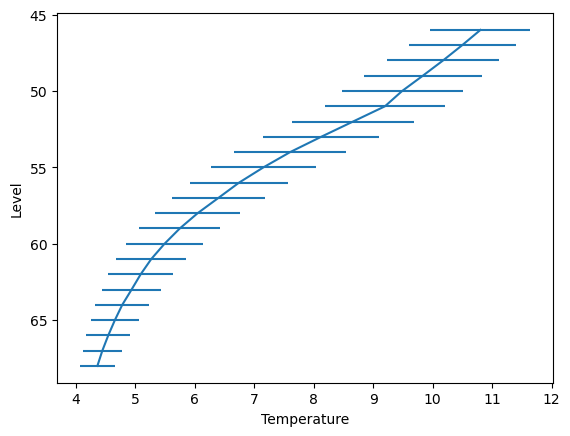

In [46]:
plt.figure()
plt.errorbar(T_mean, level, xerr=T_std)
plt.xlabel("Temperature")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

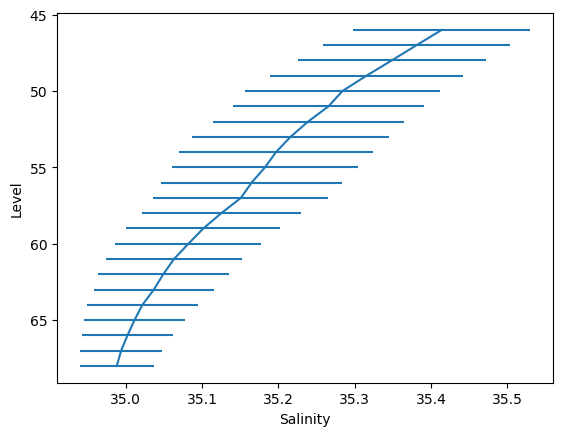

In [47]:
plt.figure()
plt.errorbar(S_mean, level, xerr=S_std)
plt.xlabel("Salinity")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

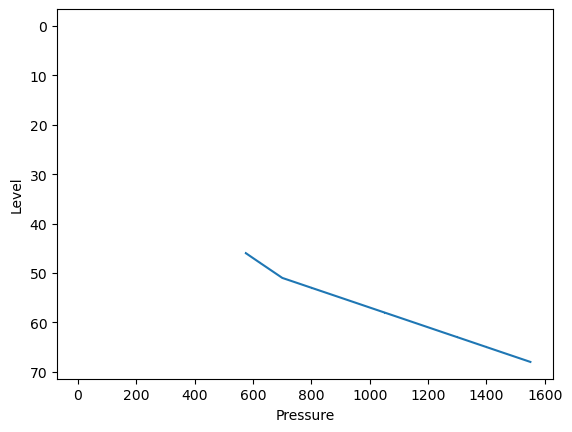

In [48]:
plt.figure()
plt.errorbar(P_mean, level, xerr=P_std)
plt.xlabel("Pressure")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

## 2.6 Account For Missing Data

In [49]:
T_mean = np.nanmean(T, axis=1)
T_std  = np.nanstd(T, axis=1)

S_mean = np.nanmean(S, axis=1)
S_std  = np.nanstd(S, axis=1)

P_mean = np.nanmean(P, axis=1)
P_std  = np.nanstd(P, axis=1)

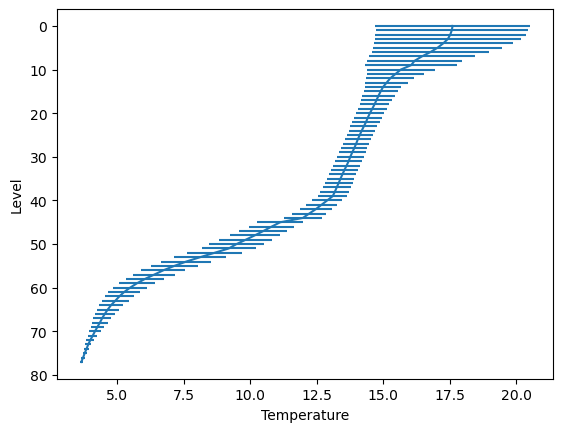

In [50]:
plt.figure()
plt.errorbar(T_mean, level, xerr=T_std)
plt.xlabel("Temperature")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

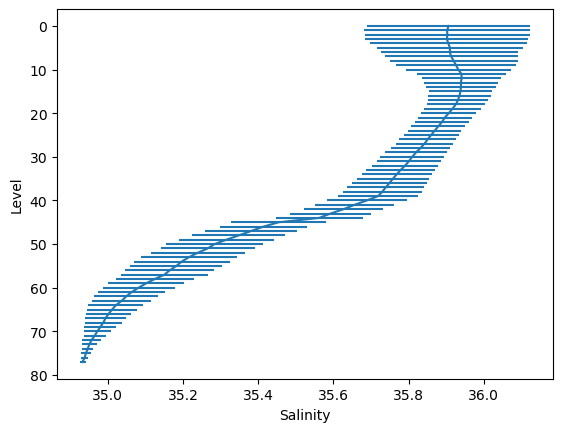

In [51]:
plt.figure()
plt.errorbar(S_mean, level, xerr=S_std)
plt.xlabel("Salinity")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

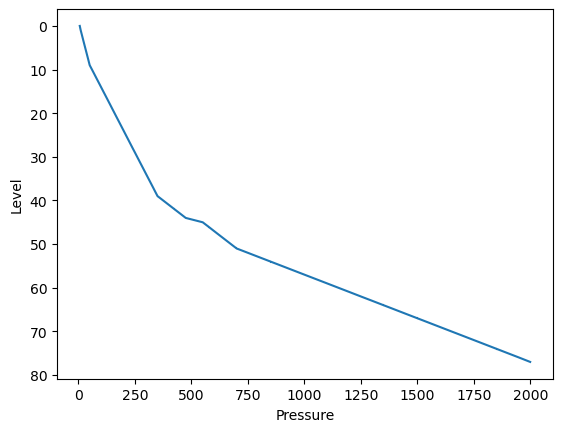

In [52]:
plt.figure()
plt.errorbar(P_mean, level, xerr=P_std)
plt.xlabel("Pressure")
plt.ylabel("Level")
plt.gca().invert_yaxis()
plt.show()

## 2.7 Create a scatter plot of the lon, lat positions of the ARGO float

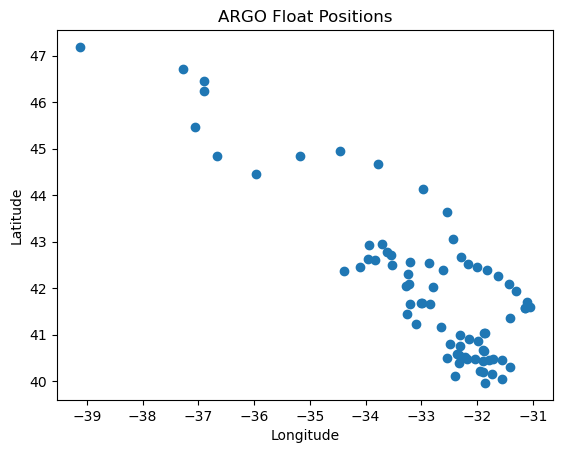

In [53]:
plt.figure()
plt.scatter(lon, lat)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("ARGO Float Positions")
plt.show()